# Breadth first search, solution 2

Load code and data for countries, cities, and roads, which form a symmetric weighted graph.

See also https://en.wikipedia.org/wiki/Breadth-first_search .

In [11]:
import os
#print(os.getcwd())

from roadbox import Country, City, Road
from roadbox import show_map, show_path

In [12]:
with open(f"countries.py", 'r', encoding="utf8") as file:
    countries = eval(file.read())

with open(f"cities.py", 'r', encoding="utf8") as file:
    cities = eval(file.read())

with open(f"roads.py", 'r', encoding="utf8") as file:
    roads = eval(file.read())

with open(f"example_paths.py", 'r', encoding="utf8") as file:
    example_paths = eval(file.read())

In [13]:
def create_map(roads):
    '''creates an adjacency map'''
    adjacency_map = {}
        
    # For every road, you need to add the road to the adjacency map in both directions.
    # If a and b are the cities, then adjacnecy_map[a][b] = distance and 
    # adjacency_map[b][a] = distance

    for road in roads:
        
        if not road.a in adjacency_map:
            adjacency_map[road.a] = {}
        adjacency_map[road.a][road.b] = road.distance

        if not road.b in adjacency_map:
            adjacency_map[road.b] = {}  
        adjacency_map[road.b][road.a] = road.distance

    return adjacency_map

adjacency_map = create_map(roads)

# Breadth-first search

We search for a path from city **a** to city **b**.

Cities (nodes) that are directly connected to the origin **a** are first-degree neighbors of **a**. Cities that are neighbors of first-degree neighbors are second degree neighbors of **a**, and so on. For the purpose of this exercise, you can only be an $n$-degree neighbor if you are not also an ($n-1$)-degree neighbor or an ($n-2$)-degree neighbor and so on, to avoid dealing with loops. 

We call each set of $n$-degree neighbors a level: the origin itself is in level $0$, the first degree neighbors are in level $1$, and so on.

With this understanding, breadth-first first checks whether **b** is a first degree neighbor of **a** If it isn't, it checks whether **b** is a second degree neighbor of **a**, and so on.

To avoid loops, we can either use a dedicated taboo-list, or the list of levels with cities that have already been visited.

#### Previous nodes and paths: 
Depth first search grows and shrinks one path. Breadth first search discovers cities level by level. When we first discover a city, we know a shortest path to it in **number of roads**. We record each city only once, so cycles cannot make us revisit it.

Suppose we discover city **y** from city **x** in level $n-1$. We place **y** in level $n$. There are three ways to retain enough information to return a path:

1. **Store complete paths**. Keep a dictionary of paths, beginning with ```paths[origin] = [origin]```. On discovering **y** from **x**, set ```paths[y] = paths[x] + [y]```. This is easy to understand but maintains a large list of paths.

2. **Store predecessors.** Set ```previous[origin] = None``` and, on discovering **y** from **x**, set ```previous[y] = x```. Once we find the destination, follow predecessors back to the origin and reverse the resulting list with ```path[::-1]```. This stores less information.

3. **Store levels**. Starting at the destination in level $n$, choose any neighboring city in level $n-1$, then one in level $n-2$, and continue to the origin. Reverse the resulting list. This works, though finding the preceding city takes another search through neighbors.

A set of **discovered** cities is the simplest way to prevent repeated visits. We could instead check whether a city appears in an earlier level, but that requires searching those levels.

In [14]:
def breadth_first(adjacency_map, origin, destination ):
    '''finds a short path by breadth first search.
    This is solution 2, which stores the predecessors.'''

    # special case
    if origin == destination:
        return [origin]

    # the first level contains the origin
    previous_level = set()
    current_level = {origin}
    previous = {origin: None}

    while True:

        next_level = set()

        for node in current_level:

            neighbors = adjacency_map[node]

            for neighbor in neighbors:

                if neighbor == destination:
                    print("found a path")

                    path = [destination]
                    current = node

                    while current is not None:
                        path.append(current)
                        current = previous[current]

                    return path[::-1] # return the reversed path

                if neighbor not in previous:

                    next_level.add(neighbor)
                    previous[neighbor] = node

        if len(next_level) == 0:
            print("no path found")
            return []
            
        previous_level = current_level
        current_level = next_level

found a path
[41, 440, 90, 684, 238, 396, 364, 657, 667, 403, 476, 205, 79, 516, 207, 490, 637, 545, 6]
path length in number of nodes: 19
path length in km: 1607.0


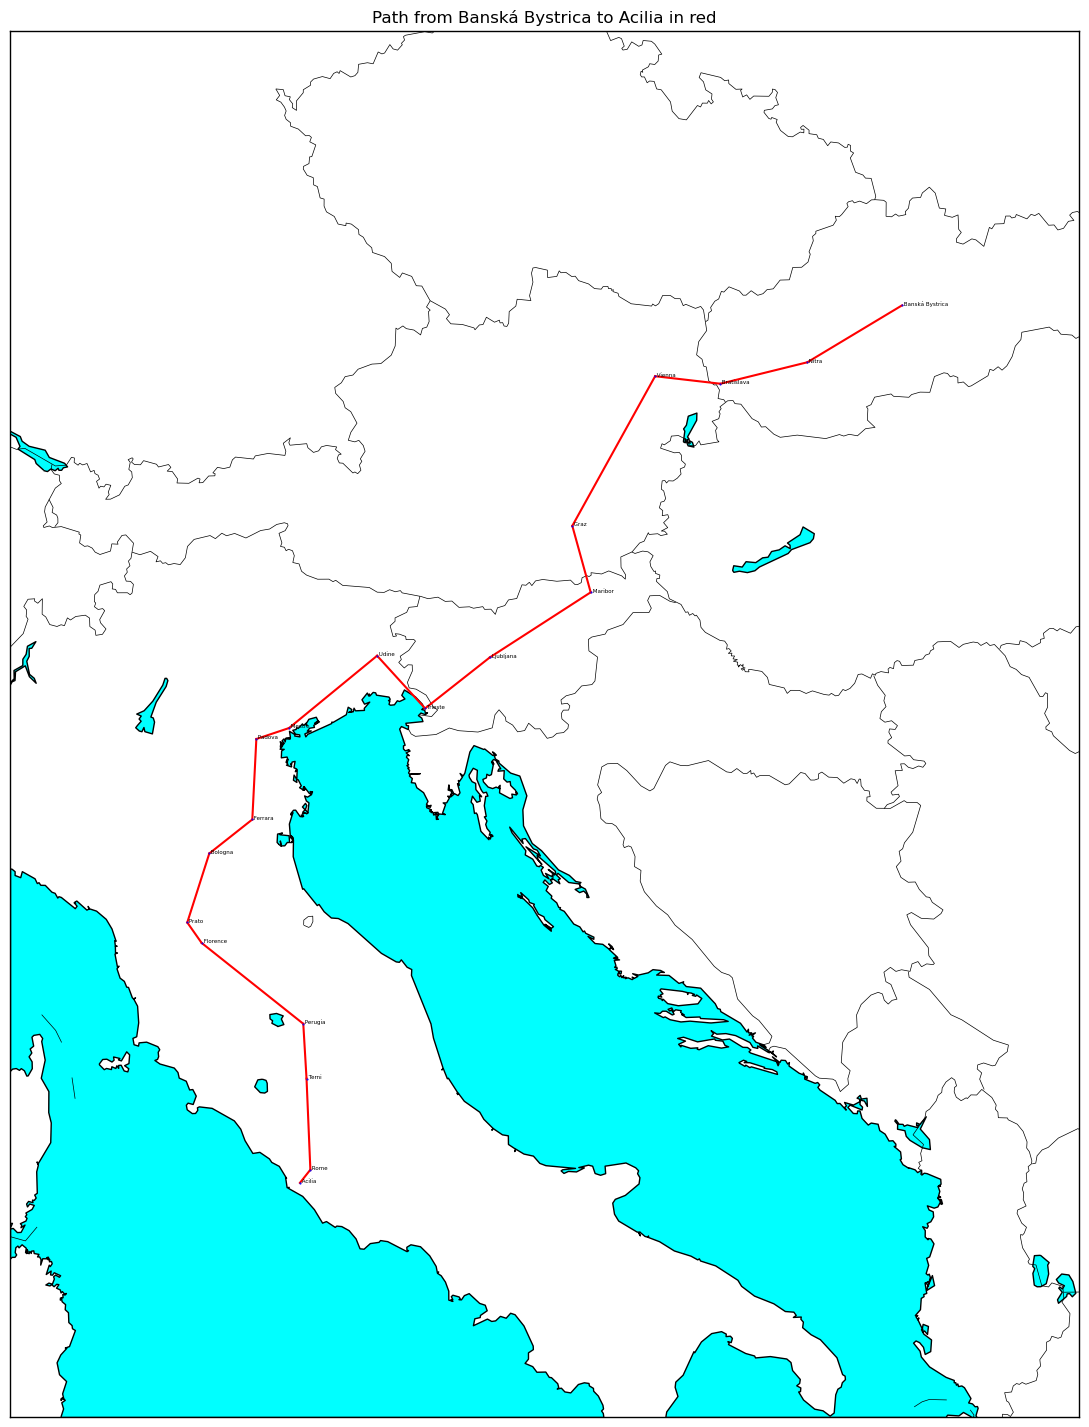

In [15]:
path = breadth_first(adjacency_map, 41, 6)
print(path)
show_path(cities, path, adjacency_map)

The red path above is the path found with breadth first. It is much shorter than the path found with depth first.